## Gradient Descent
The algorithm we use in Backpropagation and many other ML techniques for optimization

Gradient descent is a way to minimize an objective
function J(θ) parameterized by a model's parameters θ∈Rd by
updating the parameters in the opposite direction of the gradient of
the objective function ∇θJ(θ) w.r.t. to the parameters. The learning
rate η determines the size of the steps we take to reach a (local)
minimum. In other words, we follow the direction of the slope of the
surface created by the objective function downhill until we reach a
valley.

### Three variations of GD
- Batch Gradient Descent
- Stochastic Gradient Descent
- Mini-batch Gradient Descent

These variations differ by how much data is being used for updation of parameters.  
We make trade-off between accuracy of predictions and training time

### BGD Vs SGD

### 1. Batch Gradient Descent
Here, entire training dataset is taken to calculate gradients in a single iteration  


___Psuedo code:___
```python
for i in range(epochs):
    gradients = evaluate_gradient(loss_function, data, params)
    params = params - learning_rate * gradients
```


- Here, number of times weights are updated = number of epochs

### 2. Stochastic Gradient Descent
Here, one random instance from dataset is taken to compute gradients and update weights, this happens for each instance in a single iteration

___Psuedo code___:

```python
for i in range(epochs):
    np.random.shuffle(data)
    for example in data:
        gradients = evaluate_gradient(loss_function, example, params)
        params = params - learning_rate * gradients

```

- Data is shuffled to remove any bias that may be present in data
- Here, number of times weights are updated = $\text{epochs} \times \text{number of instances}$

|Differences | Batch GD | Stochastic GD |
|------------|----------|---------------|
|Number of times weights are updated| epochs | $\text{epoch} \times \text{number of instances}$|
|Which is faster (given same number of epochs)| ✅because number of times parameters updated is less | ❌ |
|Which converges faster (given same number of epochs)| ❌ | ✅ because it update the weights more number of times given the same epoch|
|How to apply | set `batch_size = total instances` | set `batch_size = 1` |

___Note___: 
- Hence, BGD is faster for same number of epochs but needs more number of epochs to converge
- While, SGD is slower for same number of epochs but converge faster

In [27]:
import kagglehub
import os 
import shutil

path = kagglehub.dataset_download("rakeshrau/social-network-ads")
print("Path to dataset files:", path)

my_path = r"C:\Users\Arun\Documents\Documents\Deep Learning\1_Introduction_To_ANNs\datasets\Socail_Network"
os.makedirs(my_path,exist_ok=True)
for filename in os.listdir(path):
    src = os.path.join(path, filename)
    dst = os.path.join(my_path, filename)
    shutil.copy(src,dst)
    print("Files copied")

Path to dataset files: C:\Users\Arun\.cache\kagglehub\datasets\rakeshrau\social-network-ads\versions\1
Files copied


In [4]:
import pandas as pd

df = pd.read_csv("datasets/Socail_Network/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df = df.drop(columns=['User ID'])
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


In [6]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['Age','EstimatedSalary']],df['Purchased'],test_size=0.2)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [9]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input , Dense

- ___Using Batch GD___

In [28]:
model = Sequential()

model.add(Input(shape=(X_scaled.shape[1],)))
model.add(Dense(10, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [29]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
import time
start = time.time()


model.compile(optimizer="Adam", loss='binary_crossentropy',metrics=['Accuracy'])
history = model.fit(x=X_scaled,y=y_train, batch_size=X_scaled.shape[0],epochs=50,verbose=1,validation_split=0.2)


time_taken = time.time() - start
print("Time taken:", time_taken)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step - Accuracy: 0.5703 - loss: 0.6917 - val_Accuracy: 0.6719 - val_loss: 0.6697
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - Accuracy: 0.5742 - loss: 0.6901 - val_Accuracy: 0.6875 - val_loss: 0.6680
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - Accuracy: 0.5742 - loss: 0.6885 - val_Accuracy: 0.7031 - val_loss: 0.6664
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - Accuracy: 0.5820 - loss: 0.6869 - val_Accuracy: 0.7031 - val_loss: 0.6648
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - Accuracy: 0.5820 - loss: 0.6853 - val_Accuracy: 0.7188 - val_loss: 0.6632
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - Accuracy: 0.5859 - loss: 0.6837 - val_Accuracy: 0.7188 - val_loss: 0.6616
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - Accuracy: 0.5977 - loss: 0.6822 - val_Accuracy: 0.7188 - val_loss: 0.6600
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - Accuracy: 0.6016 - loss: 0.6806 - val_Accuracy: 0.7344 - val_loss: 0.

- Time taking is around 6s 
- Accuracy reached is around 0.6 - 0.7

- ___Using SGD___

In [31]:
start = time.time()


model.compile(optimizer='Adam', loss='binary_crossentropy',metrics=['Accuracy'])
history = model.fit(x=X_scaled,y=y_train,batch_size=1,epochs=50,verbose=1,validation_split=0.2)

time_taken = time.time() - start
print("Time taken:", time_taken)

Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.7461 - loss: 0.5663 - val_Accuracy: 0.8125 - val_loss: 0.4957
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.7969 - loss: 0.4713 - val_Accuracy: 0.8906 - val_loss: 0.4193
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.8477 - loss: 0.4065 - val_Accuracy: 0.9219 - val_loss: 0.3717
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.8594 - loss: 0.3677 - val_Accuracy: 0.8906 - val_loss: 0.3436
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.8555 - loss: 0.3446 - val_Accuracy: 0.8906 - val_loss: 0.3252
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.8711 - loss: 0.3292 - val_Accuracy: 0.9062 - val_loss: 0.3090
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.8789 - loss: 0.3164 - val_Accuracy: 0.9062 - val_loss: 0.2968
Epoch 8/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.8789 - loss: 0.3063 - val_Accuracy: 0.

- Time taking is around 25s 
- Accuracy reached is around 0.90 - 0.95


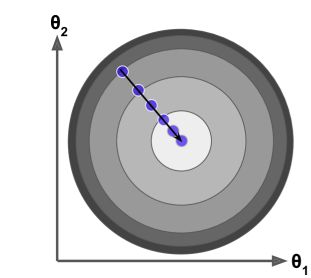
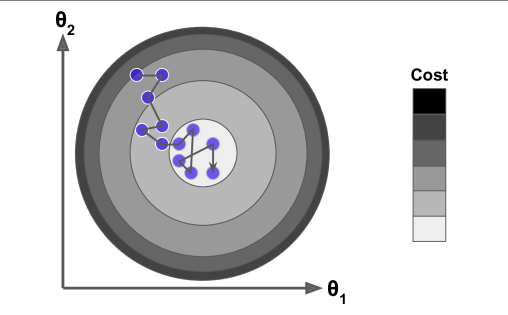

|Differences | Batch GD | Stochastic GD |
|------------|----------|---------------|
|How they converge| Smooth convergence | Random oscillatory convergence | 

### Why?
- BGD takes the entire dataset for gradient calculation and weights updation in each iteration, hence, a stable path towards minima
- SGD takes one random instance for gradient calculation and weights updation in each iteration, hence, a random oscillatory path towards minima

___Is this random behaviour of SGD useful?___:  
- Yes, if we have a loss function with multiple minimas, then batch gradient descent could be stuck in local minima based on initialization of parameters. But SGD can avoid this because of its random nature
- No, SGD may never converge and keep hopping around the minima

| BGD | SGD |
|-----|-----|
|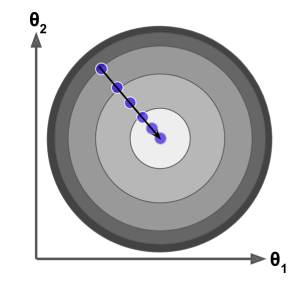|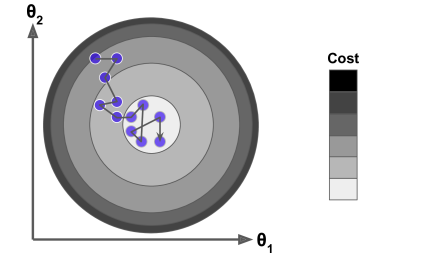|
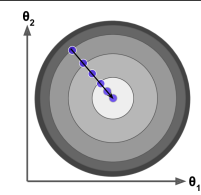
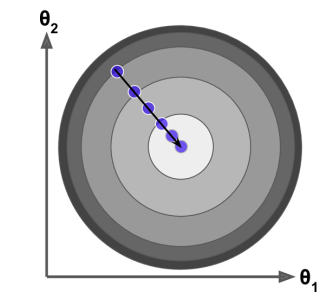

In [32]:
# Proof
import time
start = time.time()


model.compile(optimizer="Adam", loss='binary_crossentropy',metrics=['Accuracy'])
history = model.fit(x=X_scaled,y=y_train, batch_size=X_scaled.shape[0],epochs=500,verbose=1,validation_split=0.2)


time_taken = time.time() - start
print("Time taken:", time_taken)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step - Accuracy: 0.9180 - loss: 0.2232 - val_Accuracy: 0.9375 - val_loss: 0.1878
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - Accuracy: 0.9180 - loss: 0.2231 - val_Accuracy: 0.9375 - val_loss: 0.1879
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - Accuracy: 0.9180 - loss: 0.2230 - val_Accuracy: 0.9375 - val_loss: 0.1879
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - Accuracy: 0.9180 - loss: 0.2229 - val_Accuracy: 0.9375 - val_loss: 0.1880
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - Accuracy: 0.9180 - loss: 0.2229 - val_Accuracy: 0.9375 - val_loss: 0.1880
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - Accuracy: 0.9180 - loss: 0.2228 - val_Accuracy: 0.9375 - val_loss: 0.1880
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - Accuracy: 0.9180 - loss: 0.2227 - val_Accuracy: 0.9375 - val_loss: 0.1881
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - Accuracy: 0.9180 - loss: 0.2226 - val_Accuracy: 0.9375 - val_l

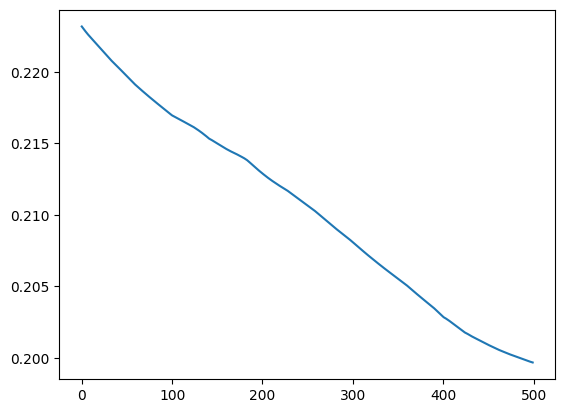

In [35]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [37]:
import time
start = time.time()


model.compile(optimizer="Adam", loss='binary_crossentropy',metrics=['Accuracy'])
history = model.fit(x=X_scaled,y=y_train, batch_size=1,epochs=100,verbose=1,validation_split=0.2)


time_taken = time.time() - start
print("Time taken:", time_taken)

Epoch 1/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9336 - loss: 0.2027 - val_Accuracy: 0.9531 - val_loss: 0.1540
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.9336 - loss: 0.2005 - val_Accuracy: 0.9531 - val_loss: 0.1553
Epoch 3/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - Accuracy: 0.9375 - loss: 0.2004 - val_Accuracy: 0.9531 - val_loss: 0.1558
Epoch 4/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.9336 - loss: 0.2000 - val_Accuracy: 0.9531 - val_loss: 0.1571
Epoch 5/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.9375 - loss: 0.2001 - val_Accuracy: 0.9531 - val_loss: 0.1585
Epoch 6/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.9375 - loss: 0.2007 - val_Accuracy: 0.9531 - val_loss: 0.1579
Epoch 7/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.9336 - loss: 0.2002 - val_Accuracy: 0.9531 - val_loss: 0.1572
Epoch 8/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - Accuracy: 0.9375 - loss: 0.1994 - val_Accu

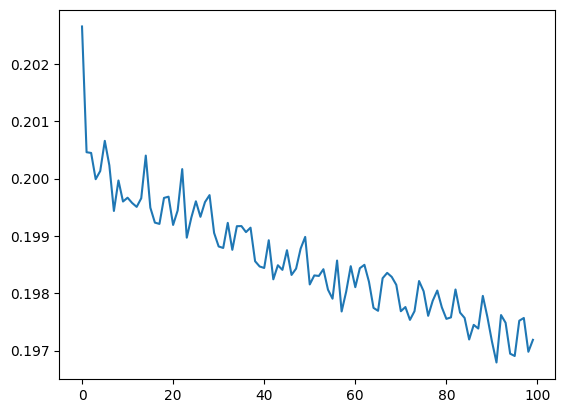

In [38]:
plt.plot(history.history['loss'])

### Mini Batch Gradient Descent
The middle ground between BGD and SGD

Psuedocode
```python
for i in range(epochs):
    np.random.shuffle(data)
    for batch in get_batches(data,batch_size=50):
        gradients = evaluate_gradients(loss_function,batch,params)
        params = params - learning_rate * gradients
```

Here   
Number of times weights updated = number of mini batchs $\times$ number of iterations

ex: if batch_size=20, number of instances=100, iterations=5  
number of times weights updated = 100/20 * 5 = 20

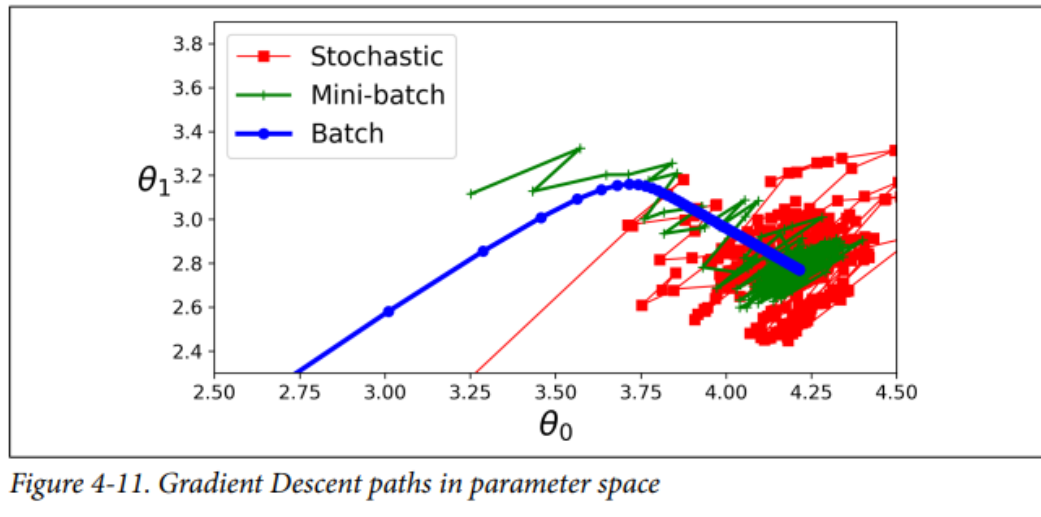

## Vanishing Gradient Problem
In Gradient Descent, during each iteration, change in weights is proportional to gradient of loss function wrt weights, but the problem is that -> If gradients will be vanishingly small and prevent weights from updating its value 

In worst case, this may cause whole neural network to stop from further training

- When it occurs generally:
    - In deep neural networks (NNs with many layers)
    - Sigmoid or Tanh type activation functions are used

Why?   
Take this example:

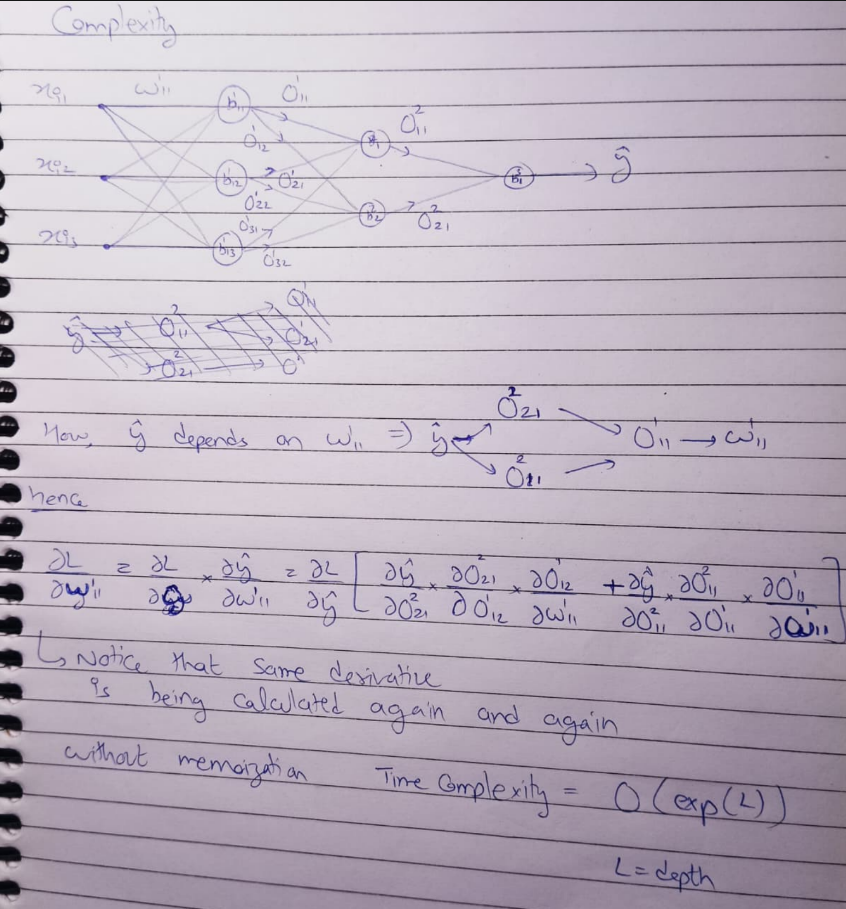

- $\frac{\partial{L}}{\partial{W^1_{11}}}$ is product of many derviatives, and if each derivative is tending to zero then product will be vanishingly small

- Also if activation function is sigmoid, $\hat{y}$ and other outputs will definitely be less than 1 (range = [0,1]).

In [17]:
## Example
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input,Dense
from keras import Sequential
from sklearn.datasets import make_moons
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

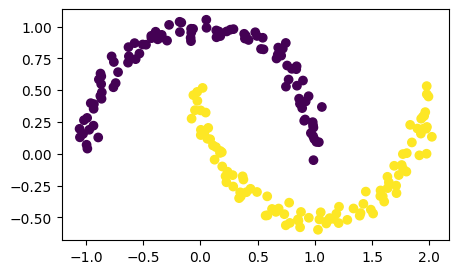

In [9]:
X,y = make_moons(n_samples=200,noise=0.05,random_state=3)

plt.figure(figsize=(5,3))
plt.scatter(X[:,0],X[:,1],c=y)

In [49]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics=['Accuracy'])

#Check initial weights (of first layer for now)
old_weights = model.get_weights()[0]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4)
history = model.fit(X_train, y_train, epochs=100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - Accuracy: 0.4750 - loss: 0.8904
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.4750 - loss: 0.8778 
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.4750 - loss: 0.8677 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.4750 - loss: 0.8567 
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.4750 - loss: 0.8465 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.4750 - loss: 0.8368 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.4750 - loss: 0.8275 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.4750 - loss: 0.8187 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.4750 - loss: 0.8100 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.4750 - loss: 0.8014 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.4750 - loss: 0.7943 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.4750 - los

In [50]:
new_weights = model.get_weights()[0]

percent_change = abs(100*(old_weights - new_weights)/ old_weights)
percent_change

array([[ 7.942075 ,  1.5466856,  0.8286539,  8.87259  , 34.128334 ,
         2.1109383,  5.436434 , 80.15412  ,  0.6633296,  8.405873 ],
       [ 1.2483542,  2.9663913,  3.221845 , 48.366844 ,  5.5734406,
         4.905119 , 18.401173 ,  9.247973 ,  3.3455653, 31.351833 ]],
      dtype=float32)

Even after 100 iterations, percentage change is negligible and hence model accuracy is bad

### Ways To Handle Vanishing Gradient Problem

- Use simple Neual Network if possible
    - But this is not applicable if data is complex and you need deep NN to train on that data
- Use different Activation function in hidden layers - ReLu is a good choice
    - Why? 
        - sigmoid squeez the outputs in range 0-1
        - relu sqeez outputs in range 0-$\infty$

- Proper Weight Initialization
- Batch Normalization
- Using residual network

In [51]:
model = Sequential()

model.add(Input(shape=(X.shape[1],)))

model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


model.compile(optimizer = 'Adam', loss = 'binary_crossentropy', metrics=['Accuracy'])

#Check initial weights (of first layer for now)
old_weights = model.get_weights()[0]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.4)
history = model.fit(X_train, y_train, epochs=100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - Accuracy: 0.5167 - loss: 0.6831
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - Accuracy: 0.5167 - loss: 0.6726
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5250 - loss: 0.6624 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5167 - loss: 0.6527 
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - Accuracy: 0.5250 - loss: 0.6440 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5583 - loss: 0.6350 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - Accuracy: 0.5583 - loss: 0.6264 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5750 - loss: 0.6173 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.5833 - loss: 0.6087 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.6083 - loss: 0.6002 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.6333 - loss: 0.5918 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - Accuracy: 0.7750 - loss

In [52]:
new_weights = model.get_weights()[0]

percent_change = abs(100*(old_weights - new_weights)/ old_weights)
percent_change

array([[ 111.799324 ,  917.35004  ,    8.719346 ,    2.3159955,
          68.962776 ,   42.82894  ,   72.48598  ,  125.15478  ,
         145.8694   ,  338.4615   ],
       [   1.8255483,  189.94614  ,  102.74568  ,   47.583897 ,
          56.587837 , 1798.9232   ,   52.37631  ,   29.605806 ,
         100.97715  ,   55.82179  ]], dtype=float32)